# Day 007: Basis Vectors & Vector Spaces (The coordinate system of AI)


## 1. Objective
> To programmatically determine if a given set of vectors qualifies as a mathematical Basis for a vector space. You will also visualize how switching to a different Basis (Coordinate Transformation) alters the geometric perspective of data.

## 2. Mathematical Foundation
> A **Vector Space** $V$ is a mathematical set where vector addition and scalar multiplication are always defined and keep you inside the set.  
> A set of vectors forms a **Basis** for that vector space if:  
> i. **Span:** Every vector in $V$ can be expressed as a linear combination of the basis vectors.  
> ii. **Independence:** The basis vectors are linearly independent (no redundancy).  
> The **Dimension** of a vector space is defined strictly as the number of vectors in its basis.  
>* **Standard Basis** for $\mathbb{R}^2$: $\mathbf{e}_1 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$, $\mathbf{e}_2 = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$.

## 3. Real-World & AI Applications
> **Business Logic (Dimensionality Reduction):** You have a dataset of customer behaviors living in a 50-dimensional vector space (50 columns). Many columns track redundant things `(total_spent, cart_value)`. By finding a new mathematical "Basis" (using an algorithm like Principal Component Analysis - PCA), you discover that you only need a 3-dimensional basis to capture 99% of the customer variance. You just reduced your database from 50D to 3D, saving massive compute costs.  
>
> 
> **AI/ML Use Case (Coordinate Transformations):** A neural network layer mathematically applies a weight matrix to input data: $\mathbf{y} = \mathbf{W}\mathbf{x}$. In linear algebra terms, this is fundamentally a **Change of Basis Transformation**. If data is jumbled up and impossible to separate in its original Standard Basis, a neural network learns to rotate and warp the grid (finding a new Coordinate System) where the distinct classes can be easily separated by a straight line.


## 4. Algorithmic Strategy
> To determine if $k$ vectors form a basis for an $n$-dimensional space ($\mathbb{R}^n$):  
> i. **Quantity Check:** Is $k == n$? If you have 3 vectors for a 2D space, they are redundant. If you have 2 vectors for a 3D space, they can't span it.  
> ii. **Independence Check:** Stack the vectors into an $n \times n$ matrix $\mathbf{A}$. Calculate its rank.  
> iii. If `rank(A) == n`, the vectors are independent and span the space. They are a Basis!

## 5. Implementation

In [1]:
import numpy as np


def is_basis(vectors: list, space_dimension: int) -> bool:
    """
    Determines if a list of vectors forms a basis for a Vector Space R^n.
    
    Parameters:
        vectors (list of np.ndarray): The proposed basis vectors.
        space_dimension (int): The dimension of the target space (e.g., 2 for R^2, 3 for R^3).
        
    Returns:
        bool: True if they form a basis, False otherwise.
    """
    # 1. Quantity Check: Must have exactly 'n' vectors for 'n' dimensional space
    if len(vectors) != space_dimension:
        print(f"Fail: Expected {space_dimension} vectors, got {len(vectors)}.")
        return False
    
    # 2. Ensure all vectors are of the correct dimension 
    for i, v in enumerate(vectors):
        if len(v) != space_dimension:
            print(f"Fail: Vector {i} has dimension {len(v)}, expected {space_dimension}.")
            return False
    
    # 3. Stack into Matrix and check Rank (Independence)
    A = np.column_stack(vectors)
    rank = np.linalg.matrix_rank(A)
    
    # 4. If Rank equals the space dimension, it is a valid Basis!
    is_valid = (rank == space_dimension)
    
    if is_valid:
        print(f"Success: Matrix rank is {rank}. These vectors form a valid Basis!")
    else:
        print(f"Fail: Matrix rank is {rank}. Vectors are linearly dependent.")
        
    return is_valid

## 6. Verification

In [2]:
# --- Test Case 1: Standard Basis ---
e1 = np.array([1, 0])
e2 = np.array([0, 1])
print("Test 1: Standard Basis")
is_basis([e1, e2], space_dimension=2)

# --- Test Case 2: Custom Valid Basis ---
v1 = np.array([1, 1])
v2 = np.array([-1, 1])
print("\nTest 2: Custom Orthogonal Basis")
is_basis([v1, v2], space_dimension=2)

# --- Test Case 3: Too Many Vectors (Dependent) ---
print("\nTest 3: Three vectors in 2D space")
is_basis([e1, e2, v1], space_dimension=2)

Test 1: Standard Basis
Success: Matrix rank is 2. These vectors form a valid Basis!

Test 2: Custom Orthogonal Basis
Success: Matrix rank is 2. These vectors form a valid Basis!

Test 3: Three vectors in 2D space
Fail: Expected 2 vectors, got 3.


False

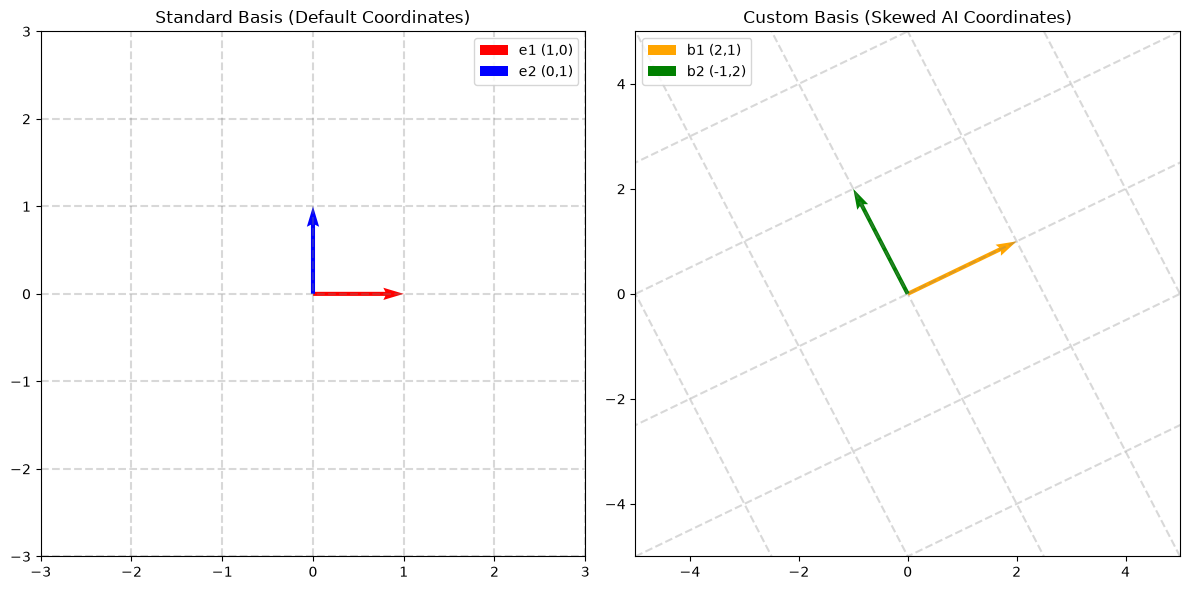

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# --- Plot 1: The Standard Basis Grid ---
ax1.quiver(0, 0, 1, 0, color='red', scale=1, scale_units='xy', angles='xy', label='e1 (1,0)')
ax1.quiver(0, 0, 0, 1, color='blue', scale=1, scale_units='xy', angles='xy', label='e2 (0,1)')

# Draw standard grid lines
for i in range(-3, 4):
    ax1.axhline(i, color='gray', linestyle='--', alpha=0.3)
    ax1.axvline(i, color='gray', linestyle='--', alpha=0.3)

ax1.set_xlim(-3, 3); ax1.set_ylim(-3, 3)
ax1.set_title("Standard Basis (Default Coordinates)")
ax1.legend()

# --- Plot 2: A Custom Basis Grid ---
# Let's use vectors that skew and rotate the space
b1 = np.array([2, 1])
b2 = np.array([-1, 2])

ax2.quiver(0, 0, b1[0], b1[1], color='orange', scale=1, scale_units='xy', angles='xy', label='b1 (2,1)')
ax2.quiver(0, 0, b2[0], b2[1], color='green', scale=1, scale_units='xy', angles='xy', label='b2 (-1,2)')

# Draw the custom skewed grid lines created by the linear combinations of b1 and b2
for i in range(-3, 4):
    # Lines parallel to b1
    p1_start = i * b2 - 3 * b1; p1_end = i * b2 + 3 * b1
    ax2.plot([p1_start[0], p1_end[0]], [p1_start[1], p1_end[1]], color='gray', linestyle='--', alpha=0.3)
    # Lines parallel to b2
    p2_start = i * b1 - 3 * b2; p2_end = i * b1 + 3 * b2
    ax2.plot([p2_start[0], p2_end[0]], [p2_start[1], p2_end[1]], color='gray', linestyle='--', alpha=0.3)

ax2.set_xlim(-5, 5); ax2.set_ylim(-5, 5)
ax2.set_title("Custom Basis (Skewed AI Coordinates)")
ax2.legend()

plt.tight_layout()
plt.show()


## 7. Complexity Analysis
> - **Time Complexity:** $\mathcal{O}(n^3)$ — Constructing the basis and checking for matrix rank using SVD is a cubic operation relative to the dimension $n$ of the space.
> - **Space Complexity:** $\mathcal{O}(n^2)$ Creating the matrix block to hold the $n$ vectors of size $n$ requires quadratic space allocation.